In [1]:
pathout = '..'

import sys
sys.path.append(pathout)
from TheModel import *

C = 15
epsi = 0.005
InInfComp = 'A and B'
alpha_atUnstEE = 0.09 # for seasonality extension
alpha_Endemic = 0.12  # for behavioral feedback extension

#Analytical
alpha_EE, Rinf_unstEq, R_inf_endEq = np.load(pathout+f'/Symmetric Model (+s)/Data/DataSIRS_EE_analytical_C={C}.npy')
alpha_EE, Ainf_unstEq, Ainf_endEq = np.load(pathout+f'/Symmetric Model (+s)/Data/DataSIRS_EE_analytical_Ainf_C={C}.npy')
R0_EE = alpha_EE/0.1   # kappa = 1 in this data. Later can use this for all kappa, because kappa always cancels in R0 = alpha/gamma.
TheMask = R0_EE <= 1

p={
    'y0':[0.995, 0.005, 0, .005, 0, .005],
    'beta': C*.08, # just to initialize
    'alpha': .08,  # just to initialize
    'gamma': .1,
    'nu': .01,
    'tmin': 0,
    'tmax': 10*360,# just to initialize
    'stepsize': 0.1,      
    'maxstep': 10,
    'direction': True,
    's': 0.25,               # seasonality amplitude
    'w': 2*np.pi/360,        # seasonality frequency (repeats after every 360days)
    'seasonalshift': 0,
    'mmax': 0.2,   # just to initialize
    'hthres': 2*1/1000,
    'epsilon_m': 2*0.00025,
    'tau': 36,
    'distinguishable': False,
}

SetInCondfullSIRS(epsi, p, InInfComp)

1

In [2]:
from scipy.optimize import root_scalar

fraction = 0.2 # R0_bif is independent of this

def Discriminant(alpha, C, gamma=0.1, nu=0.01):
    beta = alpha*C
    rho = 1+gamma/nu
    a = beta**2*rho**2
    b = beta*rho*(2*gamma+nu*rho**2-beta)
    c = beta*(gamma**2/alpha-gamma-nu*rho**2)+2*nu*gamma*rho**2
    d = (gamma/alpha-1)*nu*gamma*rho
    return -27*a**2*d**2+18*a*b*c*d-4*a*c**3-4*b**3*d+b**2*c**2

def AlphaRootOfDiscriminant_forkappa(kappa, C): # shows that the root of the discr. (bif point) in R_0=alpha/gamma is indep. of kappa
    fraction = kappa
    alpha_bif = root_scalar(lambda alpha: Discriminant(alpha, C=C, gamma=0.1/fraction, nu=0.01/fraction), bracket=[.001/fraction,1.2/fraction], method='brentq')
    print(r'result is $\alpha_{\rm bif}/\kappa=$', alpha_bif.root, r'\t or $\alpha_{\rm bif}=$',  alpha_bif.root*fraction, r'\t yielding $R_0^{\rm bif}=$', alpha_bif.root/(0.1/fraction))
    return alpha_bif.root

R0_Bif = AlphaRootOfDiscriminant_forkappa(fraction,C) / (0.1/fraction)

result is $\alpha_{\rm bif}/\kappa=$ 0.2494438257849289 \t or $\alpha_{\rm bif}=$ 0.04988876515698579 \t yielding $R_0^{\rm bif}=$ 0.4988876515698578


# For Paper

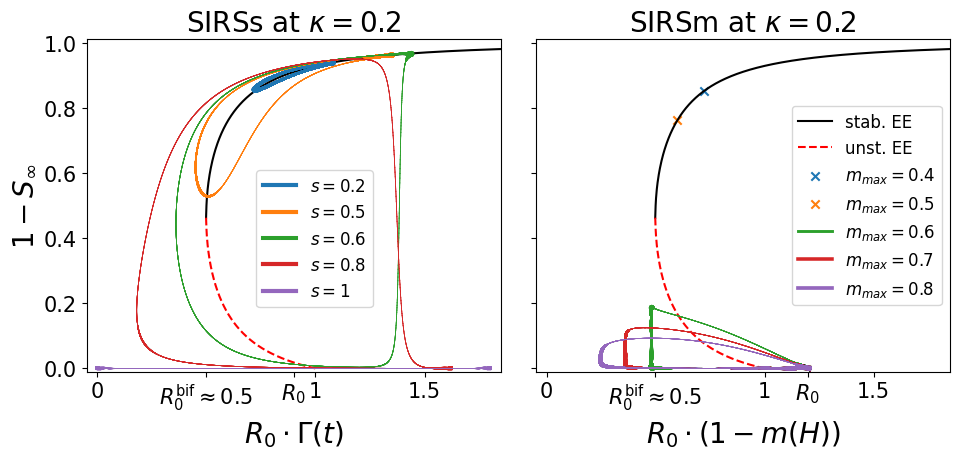

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax_seas = axes[0]
ax_mit = axes[1]
COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:] 

def bounded(x,bounds):
    '''set all values above bound[1] to bound[1] and below bound[0] to bound[0]'''
    return np.where(x>bounds[1], bounds[1], np.where(x<bounds[0], bounds[0], x))

############### Seasonality LC #####################

Trajectory = np.load('Data/DataSIRSs_LC_Examples.npy')
s_values = [0.2, 0.5, 0.6, 0.8, 1]
p['alpha'] = alpha_atUnstEE/fraction
p['gamma'] = .1/fraction
p['tmax'] = 10*360

ax_seas.plot(R0_EE, R_inf_endEq, ls='-', c='k') #, label='stab. EE')
ax_seas.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r') #, label='unst. EE.')
#PlotDFE(ax=ax_seas, x_space='R0')

for idx, s in enumerate(s_values):
    R0, Rinf = Trajectory[idx,0,:], Trajectory[idx,1,:]
    dR0 = np.gradient(R0)
    dRinf = np.gradient(Rinf)
    v = np.sqrt(dR0**2 + dRinf**2)
    v_norm = (0.0008-v) / (0.0008 + 1e-12)*3
    
    for i in range(len(R0)):
        ax_seas.plot(R0[i:i+2], Rinf[i:i+2], label=rf'$s=${s}' if i==0 else None, c=COL[idx], lw=bounded(v_norm,[0.5,3])[i])

#ax_seas.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k') #, label=r'($R_0^{\rm ref}$,$\epsilon$)')
ax_seas.set_xlabel(r'$R_0 \cdot \Gamma(t)$')
ax_seas.set_ylabel(r'$1-S_\infty$')
ax_seas.set_title(rf'SIRSs at $\kappa=${fraction}')
ax_seas.legend(loc='center', bbox_to_anchor=(0.55, 0.4))

############### Mitigation LC #####################

Trajectory = np.load('Data/DataSIRSm_LC_Examples.npy')
Labelchoice = [300,300,4500]
mmax_values = [.4, .5, .6, .7, .8]
p['alpha'] = alpha_Endemic/fraction
p['gamma'] = .1/fraction
p['tmax'] = 40*360

ax_mit.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
ax_mit.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')    
#PlotDFE(ax=ax_mit, x_space='R0')

velocities = np.empty((3,int(p['tmax']/p['stepsize']*3/10)))
acceler = np.empty((3,int(p['tmax']/p['stepsize']*3/10)))

for idx, mmax in enumerate(mmax_values):
    try:
        R0, Rinf = Trajectory[idx,0,:], Trajectory[idx,1,:]

        if(mmax>=0.55):
            # x = np.array(x)
            # y = np.array(y)
            dR0 = np.gradient(R0)
            dRinf = np.gradient(Rinf)
            
            v = np.sqrt(dR0**2 + dRinf**2)
            #dv = np.abs(np.gradient(v))
            v_norm = (0.001-v) / (0.001 + 1e-12)*3
            #a_norm = (0.3e-5-dv) / (0.3e-5 + 1e-12)*3
            velocities[idx-2,:] = np.array([v_norm])
            #acceler[idx-2,:] = np.array([a_norm])

            if(max(R0)-min(R0) < 0.01/p['gamma'] and max(Rinf)-min(Rinf) < 0.01):
                ax_mit.scatter(R0[0], Rinf[0], marker='x', label=r'$m_{max}=$'+f'{mmax}', c=COL[idx])
            else: 
                for i in range(len(R0)):
                    ax_mit.plot(R0[i:i+2], Rinf[i:i+2], lw=bounded(v_norm,[0.5,3])[i], label=r'$m_{max}=$'+f'{mmax}' if i==Labelchoice[idx-2] else None, c=COL[idx])
        else:
            if(max(R0)-min(R0) < 0.01/p['gamma'] and max(Rinf)-min(Rinf) < 0.01):
                ax_mit.scatter(R0[0], Rinf[0], marker='x', label=r'$m_{max}=$'+f'{mmax}', c=COL[idx])
            else: ax_mit.plot(R0, Rinf, label=r'$m_{max}=$'+f'{mmax}', c=COL[idx])
        
    except RuntimeError as errormessage:
        print("at mmax=",mmax,"ERROR:", errormessage)
        pass

#ax_mit.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0$,$\epsilon$)')
ax_mit.set_xlabel(r'$R_0 \cdot (1-m(H))$')
ax_mit.set_yticklabels([])
#ax_mit.set_ylabel(r'$1-S_\infty$')
ax_mit.set_title(rf'SIRSm at $\kappa=${fraction}')
ax_mit.legend(loc='center right')

##################################

for ax in axes:
    ax.set_ylim(-.01,1.01)
    ax.set_xlim(-0.05,1.85)
ax_seas.set_xticks([0,R0_Bif,alpha_atUnstEE/.1,1,1.5],labels=[0,r'$R_0^{\rm bif}\approx$0.5',r'$R_0$',1,1.5])
ax_mit.set_xticks([0,R0_Bif,1,alpha_Endemic/.1,1.5],labels=[0,r'$R_0^{\rm bif}\approx$0.5',1,r'$R_0$ ',1.5])
# ax_seas.set_xlim(-.05,1.85)
# ax_mit.set_xlim(.2,1.25)

plt.tight_layout()
plt.savefig('SIRSsORm_LCExamples_ForsingleExtension_ForPaper.png', bbox_inches='tight')
plt.savefig('SIRSsORm_LCExamples_ForsingleExtension_ForPaper.pdf', bbox_inches='tight')
plt.show()

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_28344\3000878683.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


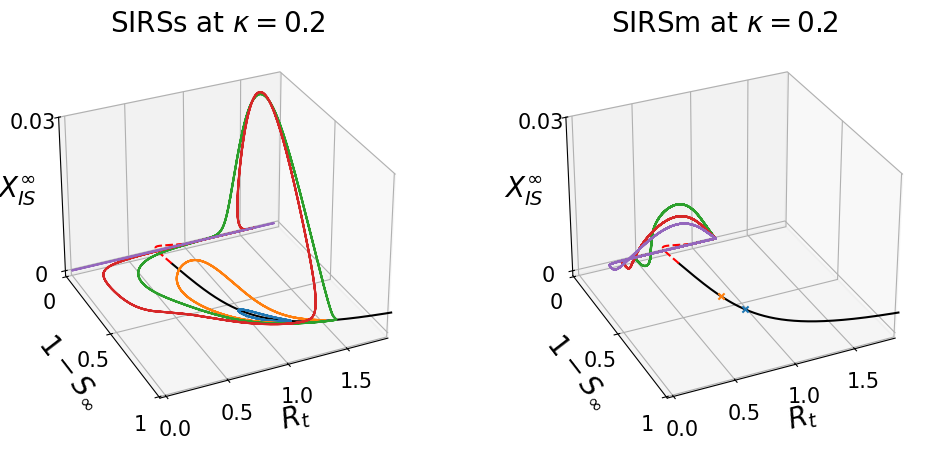

In [4]:
fig = plt.figure(figsize=(12, 5))
ax_seas = fig.add_subplot(1, 2, 1, projection='3d')
ax_mit = fig.add_subplot(1, 2, 2, projection='3d')
COL = plt.rcParams['axes.prop_cycle'].by_key()['color'][:] 

############### Seasonality LC #####################

Trajectory = np.load('Data/DataSIRSs_LC_Examples.npy')
s_values = [0.2, 0.5, 0.6, 0.8, 1]
p['alpha'] = alpha_atUnstEE/fraction
p['gamma'] = .1/fraction

ax_seas.plot(R0_EE, R_inf_endEq, Ainf_endEq, ls='-', c='k') #, label='stab. EE')
ax_seas.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], Ainf_unstEq[TheMask], ls='--', c='r') #, label='unst. EE.')
#PlotDFE(ax=ax_seas, x_space='R0')

for idx, s in enumerate(s_values):
    R0, Rinf, Ainf = Trajectory[idx,0,:], Trajectory[idx,1,:], Trajectory[idx,2,:]
    
    ax_seas.plot(R0, Rinf, Ainf, label=rf'$s=${s}', c=COL[idx])

#ax_seas.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k') #, label=r'($R_0$,$\epsilon$)')
ax_seas.set_xlabel(r'$R_t$') #= R_0^{\rm ref} \cdot \Gamma(t)$')
ax_seas.set_ylabel(r'$1-S_\infty$')
ax_seas.zaxis.set_rotate_label(False)
ax_seas.set_zlabel(r'$X_{IS}^{\infty}$', labelpad=0)
ax_seas.set_title(rf'SIRSs at $\kappa=${fraction}')
#ax_seas.legend(loc='center', bbox_to_anchor=(0.6, 0.4))

############### Mitigation LC #####################

Trajectory = np.load('Data/DataSIRSm_LC_Examples.npy')
Labelchoice = [300,300,4500]
mmax_values = [.4, .5, .6, .7, .8]
p['alpha'] = alpha_Endemic/fraction
p['gamma'] = .1/fraction

ax_mit.plot(R0_EE, R_inf_endEq, Ainf_endEq, ls='-', c='k', label='stab. EE')
ax_mit.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], Ainf_unstEq[TheMask], ls='--', c='r', label='unst. EE')    
#PlotDFE(ax=ax_mit, x_space='R0')

velocities = np.empty((3,int(p['tmax']/p['stepsize']*3/10)))
acceler = np.empty((3,int(p['tmax']/p['stepsize']*3/10)))

for idx, mmax in enumerate(mmax_values):
    try:
        R0, Rinf, Ainf = Trajectory[idx,0,:], Trajectory[idx,1,:], Trajectory[idx,2,:]

        if(max(R0)-min(R0) < 0.01/p['gamma'] and max(Rinf)-min(Rinf) < 0.01 and max(Ainf)-min(Ainf) < 0.01):
            ax_mit.scatter(R0[0], Rinf[0], Ainf[0], marker='x', label=r'$m_{max}=$'+f'{mmax}', c=COL[idx])
        else: ax_mit.plot(R0, Rinf, Ainf, label=r'$m_{max}=$'+f'{mmax}', c=COL[idx])
        
    except RuntimeError as errormessage:
        print("at mmax=",mmax,"ERROR:", errormessage)
        pass

#ax_mit.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0$,$\epsilon$)')
ax_mit.set_xlabel(r'$R_t$') #= R_0^{\rm ref} \cdot (1-m(H))$')
ax_mit.set_ylabel(r'$1-S_\infty$')
ax_mit.zaxis.set_rotate_label(False)
ax_mit.set_zlabel(r'$X_{IS}^{\infty}$', labelpad=0)
ax_mit.set_title(rf'SIRSm at $\kappa=${fraction}')
#ax_mit.legend(loc='center right')

##################################

for ax in [ax_seas, ax_mit]:
    ax.set_ylim(-.01,1.01)
    ax.set_zlim(-0.001,0.03)
    ax.set_xlim(-.05,1.85)
    ax.set_zticks([0,0.03], labels=[0,0.03])
    ax.set_yticks([0,0.5,1], labels=[0,0.5,1])
# ax_seas.set_xticks([0,R0_Bif,alpha_atUnstEE/.1,1,1.5],labels=[0,r'$R_0^{\rm bif}\approx$0.5',r'$R_0^{\rm ref}$',1,1.5])
# ax_mit.set_xticks([0,R0_Bif,1,alpha_Endemic/.1,1.5],labels=[0,r'$R_0^{\rm bif}\approx$0.5',1,r'$R_0^{\rm ref}$ ',1.5])
# ax_seas.set_xlim(-.05,1.7)
# ax_mit.set_xlim(.2,1.25)

ax_seas.invert_xaxis()
ax_mit.invert_xaxis()
ax_seas.view_init(elev=30, azim=65) # view point
ax_mit.view_init(elev=30, azim=65) # view point

plt.tight_layout()
plt.savefig('SIRSsORm_LCExamples_ForsingleExtension_R-A-R0-space_ForPaper.png', bbox_inches='tight')
plt.savefig('SIRSsORm_LCExamples_ForsingleExtension_R-A-R0-space_ForPaper.pdf', bbox_inches='tight')
plt.show()